# 05｜Iris 邏輯斯迴歸與多類別

第三週銜接補充；對應 `03_分類與模型評估.md` 的 sigmoid、decision score、OvR／OvO。課堂可選前半約 15 分鐘，多類別實作留課後。

## 來源與改編界線
- [leonjyentub/MachineLearning2025 / 01_Logistic_Regression_scratch_Iris1.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/01_Logistic_Regression_scratch_Iris1.ipynb)：儲存格 3–8 的資料切分、縮放與 LogisticRegressionGD
- [leonjyentub/MachineLearning2025 / 01_Logistic_Regression_scratch_Iris2.ipynb](https://github.com/leonjyentub/MachineLearning2025/blob/3da2cb56b9efd17d7cd34602589f392554b40603/01_Logistic_Regression_scratch_Iris2.ipynb)：儲存格 3–7 的 OvR／OvO
- [ageron/handson-mlp / 04_training_linear_models.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/04_training_linear_models.ipynb)：Logistic Regression 章節
- [ageron/handson-mlp / 03_classification.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/03_classification.ipynb)：Multiclass Classification 章節

**本課程修改／補充：** 手寫類別沿用 net_input／activation／cost_ 教學結構；改用穩定 expit／logaddexp 及平均梯度。Iris2 改為先切分再縮放，OvR／OvO 以真實類別映射，並明示平手政策。另補一格對齊投影片，示範分類正確但機率與交叉熵不同。

來源固定至上述 commit；原檔保留於 `../upstream/`，逐檔 SHA-256 見 `../upstream/manifest.json`。Géron 程式依 Apache-2.0 改編，授權原文保留。儲存格索引從 0 起算。圖表與數值是本 Notebook 重跑結果，不能直接當成書中成效。

從第一格依序執行；各本可獨立重跑。Python 環境與資料準備見 [操作說明](../README.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 先切分，再標準化

二元範例使用 setosa 與 versicolor 的花瓣長／寬。四個原始欄位中挑選兩欄，是預先指定的教學設定；不根據 test 誤差挑欄。

In [2]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, ConfusionMatrixDisplay
from scipy.special import expit
iris=load_iris()
mask=iris.target!=2
X=iris.data[mask,2:4];y=iris.target[mask]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.3,stratify=y,random_state=SEED)
scaler=StandardScaler().fit(X_train)
Z_train=scaler.transform(X_train);Z_test=scaler.transform(X_test)
assert np.allclose(scaler.mean_,X_train.mean(axis=0))
print('Training / test:',len(y_train),len(y_test))

Training / test: 70 30


## 2. 用平均 log loss 做梯度下降

$z=w^Tx+b$，$p=\sigma(z)$；以 `logaddexp(0,z) - y*z` 計算 loss，避免直接 `log(0)`。由原版「梯度加總」改為平均後，學習率尺度不同，不能原封不動比較每輪數字。

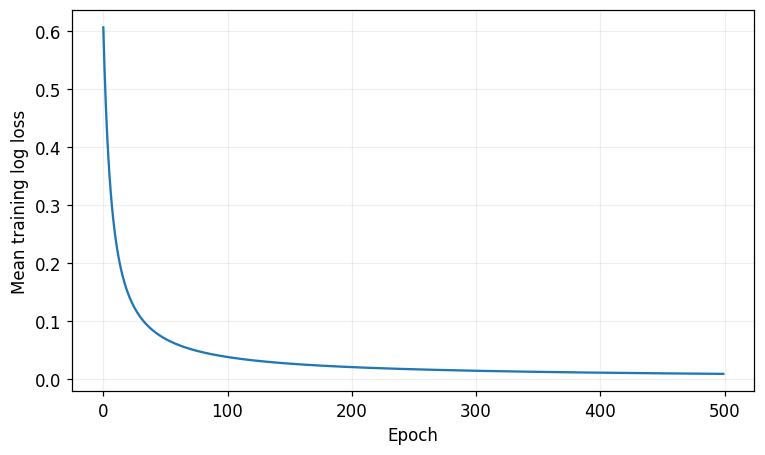

In [3]:
class LogisticRegressionGD:
    def __init__(self,eta=.2,n_iter=500,random_state=42):
        self.eta=eta;self.n_iter=n_iter;self.random_state=random_state
    def fit(self,X,y):
        X=np.asarray(X,dtype=float);y=np.asarray(y)
        if not set(np.unique(y)) <= {0,1}:
            raise ValueError('This teaching classifier expects 0/1 targets')
        self.w_=np.random.default_rng(self.random_state).normal(0,.01,X.shape[1]+1)
        self.cost_=[]
        for _ in range(self.n_iter):
            z=self.net_input(X);error=self.activation(z)-y
            self.w_[1:] -= self.eta*(X.T@error)/len(X)
            self.w_[0] -= self.eta*error.mean()
            z=self.net_input(X)
            self.cost_.append(np.mean(np.logaddexp(0,z)-y*z))
        return self
    def net_input(self,X):
        return np.asarray(X)@self.w_[1:]+self.w_[0]
    def activation(self,z):
        return expit(z)
    def predict(self,X):
        return (self.net_input(X)>=0).astype(int)
model=LogisticRegressionGD().fit(Z_train,y_train)
assert np.isfinite(model.cost_).all()
assert np.isfinite(np.logaddexp(0,np.array([-1e4,1e4]))).all()
plt.plot(model.cost_);plt.xlabel('Epoch');plt.ylabel('Mean training log loss')
savefig('05_logistic_loss')

## 補充：分類正確不代表損失相同

對應投影片「訓練損失與分類正確率不同」。固定真實類別為正類（$y=1$），只改變模型輸出機率 $\hat p$，比較 $t=0.5$ 下的分類是否正確與二元交叉熵 $-\ln\hat p$。分類結果相同時，機率估計與損失仍可能差很多。

In [4]:
p_hat=np.array([.9,.6,.1])
ce_demo=pd.DataFrame({'p_hat':p_hat,
                      'class_at_0.5':np.where(p_hat>=.5,'correct','wrong'),
                      'cross_entropy':-np.log(p_hat)})
assert np.allclose(ce_demo.cross_entropy,[0.105,0.511,2.303],atol=5e-4)
ce_demo

,p_hat,class_at_0.5,cross_entropy
0,0.9,correct,0.105361
1,0.6,correct,0.510826
2,0.1,wrong,2.302585


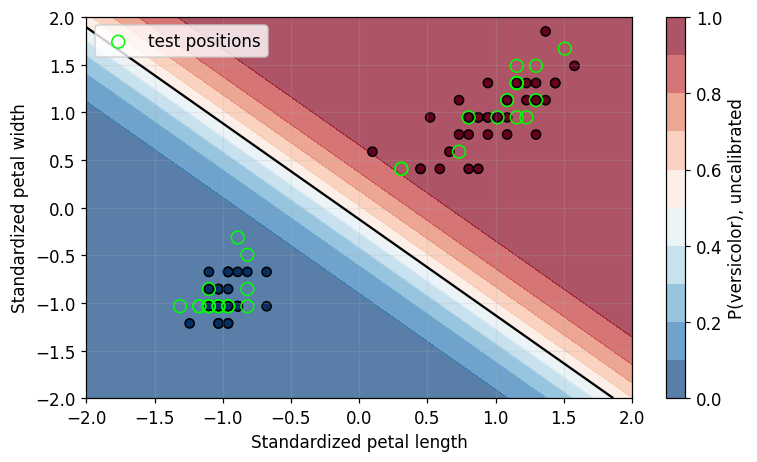

Test accuracy: 1.0
Test log loss: 0.011721584606947787


In [5]:
xx,yy=np.meshgrid(np.linspace(-2,2,160),np.linspace(-2,2,160))
prob=model.activation(model.net_input(np.c_[xx.ravel(),yy.ravel()])).reshape(xx.shape)
plt.contourf(xx,yy,prob,levels=np.linspace(0,1,11),cmap='RdBu_r',alpha=.7)
plt.colorbar(label='P(versicolor), uncalibrated')
plt.contour(xx,yy,prob,levels=[.5],colors='black')
plt.scatter(Z_train[:,0],Z_train[:,1],c=y_train,cmap='RdBu_r',edgecolor='k')
plt.scatter(Z_test[:,0],Z_test[:,1],facecolors='none',edgecolors='lime',s=70,label='test positions')
plt.xlabel('Standardized petal length');plt.ylabel('Standardized petal width');plt.legend()
savefig('05_logistic_boundary')
# 固定設定的最後測試；不再依此調 eta 或 epoch。
print('Test accuracy:',accuracy_score(y_test,model.predict(Z_test)))
print('Test log loss:',log_loss(y_test,model.activation(model.net_input(Z_test))))

容易分開的 Iris 二分類可能出現 100% accuracy；不代表所有花種、所有量測條件都能完美分類。概率數值也未經校準驗證。

## 3. 三類別：手寫 OvR 與 OvO

這是一個獨立、預先指定的三類實驗，使用四個特徵。先分割，縮放器只 fit 三類訓練集。OvR 使用最高 decision score；OvO 多數票平手時取 classes 排序中第一類（明示簡化政策）。正式套件可能採分數打破平手，因此結果未必完全一致。

In [6]:
from itertools import combinations
X_train3,X_test3,y_train3,y_test3=train_test_split(iris.data,iris.target,test_size=.3,stratify=iris.target,random_state=SEED)
scale3=StandardScaler().fit(X_train3)
Z_train3=scale3.transform(X_train3);Z_test3=scale3.transform(X_test3)
classes=np.unique(y_train3)
ovr=[LogisticRegressionGD(n_iter=800).fit(Z_train3,(y_train3==c).astype(int)) for c in classes]
def predict_ovr(Z):
    return classes[np.column_stack([m.net_input(Z) for m in ovr]).argmax(axis=1)]
ovo=[]
for c1,c2 in combinations(classes,2):
    pair=np.isin(y_train3,[c1,c2])
    binary=LogisticRegressionGD(n_iter=800).fit(Z_train3[pair],(y_train3[pair]==c1).astype(int))
    ovo.append((binary,c1,c2))
def predict_ovo(Z):
    votes=np.zeros((len(Z),len(classes)),dtype=int)
    positions={label:i for i,label in enumerate(classes)}
    for m,c1,c2 in ovo:
        positive=m.predict(Z)==1
        votes[:,positions[c1]]+=positive
        votes[:,positions[c2]]+=~positive
    return classes[votes.argmax(axis=1)],votes
ovo_pred,votes=predict_ovo(Z_test3)
assert np.all(votes.sum(axis=1)==len(ovo))
print('K classes:',len(classes),'OvR models:',len(ovr),'OvO models:',len(ovo))
results={'binary_test_accuracy':accuracy_score(y_test,model.predict(Z_test)),
         'OvR_test_accuracy':accuracy_score(y_test3,predict_ovr(Z_test3)),
         'OvO_test_accuracy':accuracy_score(y_test3,ovo_pred),
         'OvO_vote_ties':int(((votes==votes.max(axis=1,keepdims=True)).sum(axis=1)>1).sum())}
report('iris',results)
pd.Series(results)

K classes: 3 OvR models: 3 OvO models: 3


binary_test_accuracy    1.000000
OvR_test_accuracy       0.844444
OvO_test_accuracy       0.911111
OvO_vote_ties           0.000000
dtype: float64

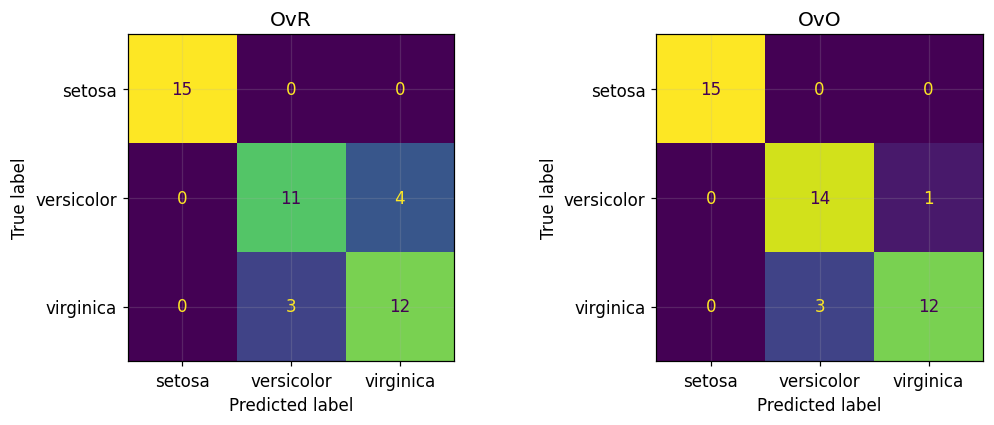

In [7]:
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,(name,pred) in zip(axes,[('OvR',predict_ovr(Z_test3)),('OvO',ovo_pred)]):
    ConfusionMatrixDisplay.from_predictions(y_test3,pred,display_labels=iris.target_names,ax=ax,colorbar=False)
    ax.set_title(name)
plt.tight_layout();savefig('05_iris_multiclass')

## 練習與參考答案

- 10 類時需多少分類器？**OvR：10；OvO：45。**
- OvR 的三個 sigmoid 輸出是否必然加總為 1？**否，三個獨立二分類器並無此約束。**
- 在 split 前對所有 Iris fit scaler，為何不合適？**test 的均值與標準差參與訓練資料轉換；即使此例分數沒變，流程仍有洩漏。**